In [38]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
website = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE169nnn/GSE169598/matrix/GSE169598_series_matrix.txt.gz"
data_path = "fajciarky_data/data.txt"
data_path_zip = "fajciarky_data/data.txt.gz"

In [40]:

!curl $website --create-dirs -o $data_path_zip
!gunzip $data_path_zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  333M  100  333M    0     0  10.5M      0  0:00:31  0:00:30  0:00:01 10.7M  0:00:13  0:00:16 12.7M     0  10.1M      0  0:00:32  0:00:18  0:00:14 7313k00:31  0:00:31 --:--:-- 11.5M


In [43]:
skiprow = None

with open(data_path, "r") as f:

    for i, line in enumerate(f):

        if line.startswith("\"ID_REF\""):
            skiprow = i
            break

print("Table starts at row:", skiprow)

Table starts at row: 64


In [44]:
df = pd.read_csv(
    data_path,
    sep="\t",
    comment="!",
    header=0,
    skiprows=skiprow
)

df.set_index("ID_REF", inplace=True)

print("\nOriginal shape:")
print(df.shape)


Original shape:
(714666, 96)


In [45]:
print("\nFirst rows:")
print(df.head())



First rows:
            GSM5210464  GSM5210465  GSM5210466  GSM5210467  GSM5210468  \
ID_REF                                                                   
cg00000029    0.006342    0.101510    0.042916    0.101567    0.114736   
cg00000109    0.911428    0.924547    0.926018    0.920207    0.925702   
cg00000155    0.948963    0.936607    0.946371    0.951434    0.949158   
cg00000158    0.955034    0.954614    0.964843    0.958018    0.954761   
cg00000165    0.602739    0.654239    0.635608    0.514626    0.569226   

            GSM5210469  GSM5210470  GSM5210471  GSM5210472  GSM5210473  ...  \
ID_REF                                                                  ...   
cg00000029    0.129332    0.134621    0.105126    0.116374    0.115263  ...   
cg00000109    0.920111    0.928904    0.930301    0.936867    0.929511  ...   
cg00000155    0.941937    0.940608    0.952269    0.940826    0.945244  ...   
cg00000158    0.952986    0.948309    0.949837    0.964955    0.958335  .

In [46]:
df = df.astype(float)

df = df.T

print("\nTransposed shape:")
print(df.shape)


Transposed shape:
(96, 714666)


In [47]:
print("\nFirst rows after transpose:")
print(df.head())


First rows after transpose:
ID_REF      cg00000029  cg00000109  cg00000155  cg00000158  cg00000165  \
GSM5210464    0.006342    0.911428    0.948963    0.955034    0.602739   
GSM5210465    0.101510    0.924547    0.936607    0.954614    0.654239   
GSM5210466    0.042916    0.926018    0.946371    0.964843    0.635608   
GSM5210467    0.101567    0.920207    0.951434    0.958018    0.514626   
GSM5210468    0.114736    0.925702    0.949158    0.954761    0.569226   

ID_REF      cg00000221  cg00000236  cg00000289  cg00000292  cg00000321  ...  \
GSM5210464    0.919096    0.829139    0.854049    0.640229    0.568796  ...   
GSM5210465    0.912881    0.864159    0.833509    0.706422    0.642472  ...   
GSM5210466    0.915767    0.825087    0.844758    0.597064    0.607435  ...   
GSM5210467    0.910884    0.828211    0.776141    0.575917    0.461922  ...   
GSM5210468    0.908985    0.819156    0.792884    0.680974    0.634972  ...   

ID_REF      cg27665860  cg27665913  cg27665925  cg2

In [48]:
metadata = {}

with open(data_path, "r") as file:

    characteristic_counter = 0

    for line in file:
        if line.startswith("!Sample_title"):

            metadata["title"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):

            metadata["accession"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_characteristics_ch1"):

            values = line.strip().split("\t")[1:]
            
            if characteristic_counter == 0:
                metadata["sex"] = values
            elif characteristic_counter == 1:
                metadata["gestational_age"] = values
            elif characteristic_counter == 2:
                metadata["smoke_type"] = values

            characteristic_counter += 1
        elif line.startswith("!series_matrix_table_begin"):
            break

meta_df = pd.DataFrame(metadata)
meta_df = meta_df.applymap(lambda x: x.replace('"', ''))
print(meta_df.columns)

Index(['title', 'accession', 'sex', 'gestational_age', 'smoke_type'], dtype='object')


/var/folders/9c/cghhh9pn5tx01rr31vbtfjkw0000gn/T/ipykernel_34283/1541953412.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  meta_df = meta_df.applymap(lambda x: x.replace('"', ''))


In [49]:
print(meta_df.head())


             title   accession     sex              gestational_age  \
0  placental DNA 1  GSM5210464  Sex: F  gestational age weeks: 39.4   
1  placental DNA 2  GSM5210465  Sex: F  gestational age weeks: 39.3   
2  placental DNA 3  GSM5210466  Sex: F  gestational age weeks: 39.3   
3  placental DNA 4  GSM5210467  Sex: M  gestational age weeks: 39.7   
4  placental DNA 5  GSM5210468  Sex: F  gestational age weeks: 37.7   

           smoke_type  
0  smoking: nonsmoker  
1     smoking: smoker  
2  smoking: nonsmoker  
3     smoking: smoker  
4     smoking: smoker  


In [50]:
for col in meta_df.columns:

    print("COLUMN:", col)

    print(meta_df[col].unique()[:20])

COLUMN: title
['placental DNA 1' 'placental DNA 2' 'placental DNA 3' 'placental DNA 4'
 'placental DNA 5' 'placental DNA 6' 'placental DNA 7' 'placental DNA 8'
 'placental DNA 9' 'placental DNA 10' 'placental DNA 11'
 'placental DNA 12' 'placental DNA 13' 'placental DNA 14'
 'placental DNA 15' 'placental DNA 16' 'placental DNA 17'
 'placental DNA 18' 'placental DNA 19' 'placental DNA 20']
COLUMN: accession
['GSM5210464' 'GSM5210465' 'GSM5210466' 'GSM5210467' 'GSM5210468'
 'GSM5210469' 'GSM5210470' 'GSM5210471' 'GSM5210472' 'GSM5210473'
 'GSM5210474' 'GSM5210475' 'GSM5210476' 'GSM5210477' 'GSM5210478'
 'GSM5210479' 'GSM5210489' 'GSM5210490' 'GSM5210491' 'GSM5210492']
COLUMN: sex
['Sex: F' 'Sex: M']
COLUMN: gestational_age
['gestational age weeks: 39.4' 'gestational age weeks: 39.3'
 'gestational age weeks: 39.7' 'gestational age weeks: 37.7'
 'gestational age weeks: 38.4' 'gestational age weeks: 38.1'
 'gestational age weeks: 38.0' 'gestational age weeks: 42.4'
 'gestational age weeks: 

In [51]:
def create_label(smoke_value):

    value = smoke_value.lower()

    if "nonsmoker" in value:
        return "NonSmoker"

    elif "smoker" in value:
        return "Smoker"

    else:
        return "Unknown"
    
meta_df["label"] = meta_df["smoke_type"].apply(create_label)

print("\nLabel counts:")
print(meta_df["label"].value_counts())


Label counts:
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [52]:
meta_df = meta_df.set_index("accession")

y = meta_df.loc[df.index, "label"]

X = df.copy()

print(X.shape)
print(y.value_counts())

(96, 714666)
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
meta_df_train = meta_df.loc[X_train.index]
meta_df_test = meta_df.loc[X_test.index]

In [90]:
"""variances = X.var(axis=0)

top_features = variances.sort_values(ascending=False).head(10000).index

X_filtered = X[top_features]

print("\nAfter feature filtering:")
print(X_filtered.shape)"""
# 1. compute variances ONLY on training data
variances = X_train.var(axis=0)

# 2. select top-k features based on training set only
top_k = 20_000
top_features = variances.sort_values(ascending=False).head(top_k).index

# 3. filter both train and test using SAME features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]

print("\nAfter feature filtering:")
print("Train shape:", X_train_filtered.shape)
print("Test shape:", X_test_filtered.shape)


After feature filtering:
Train shape: (76, 20000)
Test shape: (20, 20000)


In [91]:
"""from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X_small = X_filtered

model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=25,
    direction="forward",
    scoring="accuracy",
    cv=2,
    n_jobs=-1
)

sfs.fit(X_small, y)

X_selected = sfs.transform(X_small)

print("Selected shape:", X_selected.shape)"""

"""from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

X_small = X_filtered

selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X_small, y)

print("Selected shape:", X_selected.shape)"""
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)
X_train_kbest = selector.fit_transform(X_train_filtered, y_train)
X_test_kbest = selector.transform(X_test_filtered)


print("KBest shape:", X_train_kbest.shape)

KBest shape: (76, 100)


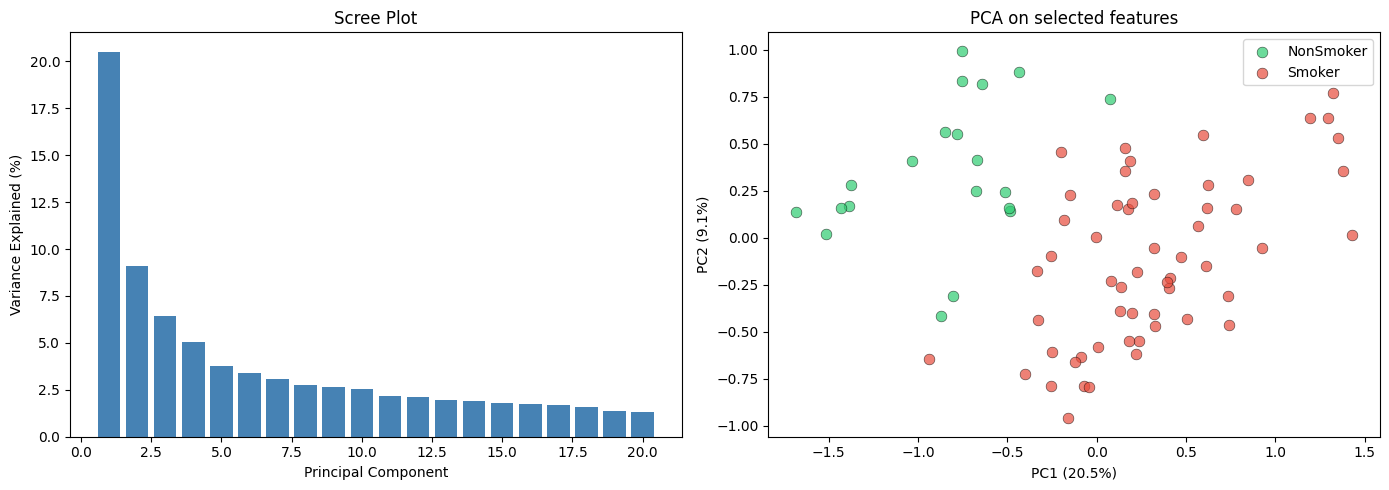

In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)
#pca = PCA(n_components=0.95, random_state=42)
#PCs = pca.fit_transform(X_selected)
PCs = pca.fit_transform(X_train_kbest)
#TODO PCs_test = pca.transform(X_test_kbest)

#scree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar(range(1, 21), pca.explained_variance_ratio_ * 100, color='steelblue')
#axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

#pc1 vs pc2
colors = {'Smoker': '#e74c3c', 'NonSmoker': '#2ecc71'}
#for label, grp in pd.DataFrame({'PC1': PCs[:,0], 'PC2': PCs[:,1], 'label': y.values}).groupby('label'):
 #   axes[1].scatter(grp['PC1'], grp['PC2'], label=label,
  #                  color=colors[label], alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
for label, grp in pd.DataFrame({'PC1': PCs[:,0], 'PC2': PCs[:,1], 'label': y_train.values}).groupby('label'):
    axes[1].scatter(grp['PC1'], grp['PC2'], label=label,
                    color=colors[label], alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA on selected features')

axes[1].legend()

plt.tight_layout()
plt.show()

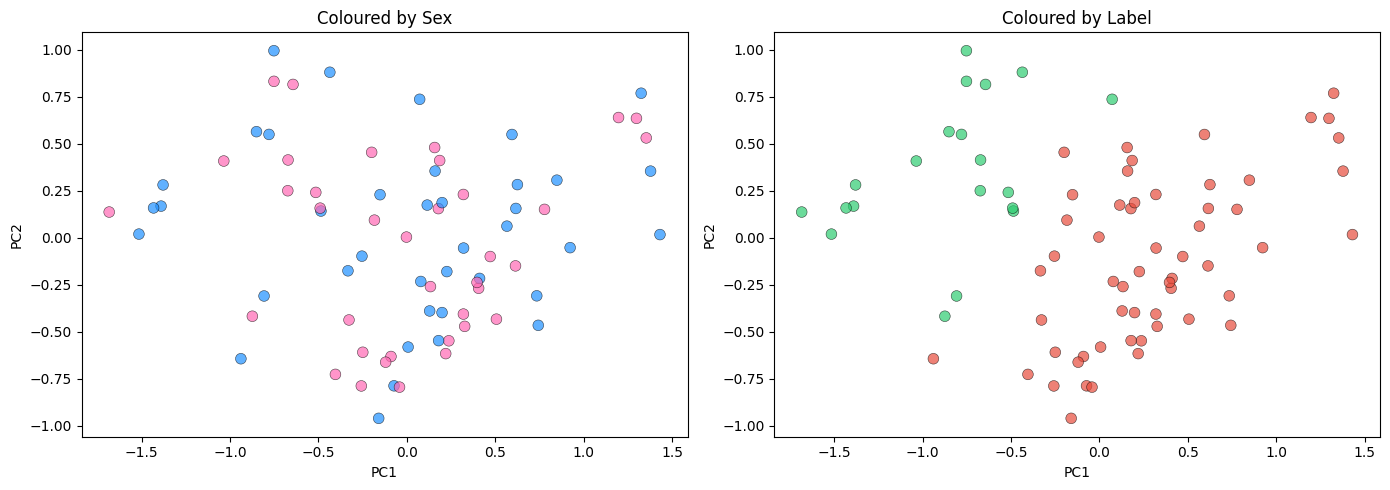

/var/folders/9c/cghhh9pn5tx01rr31vbtfjkw0000gn/T/ipykernel_34283/2668063429.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')


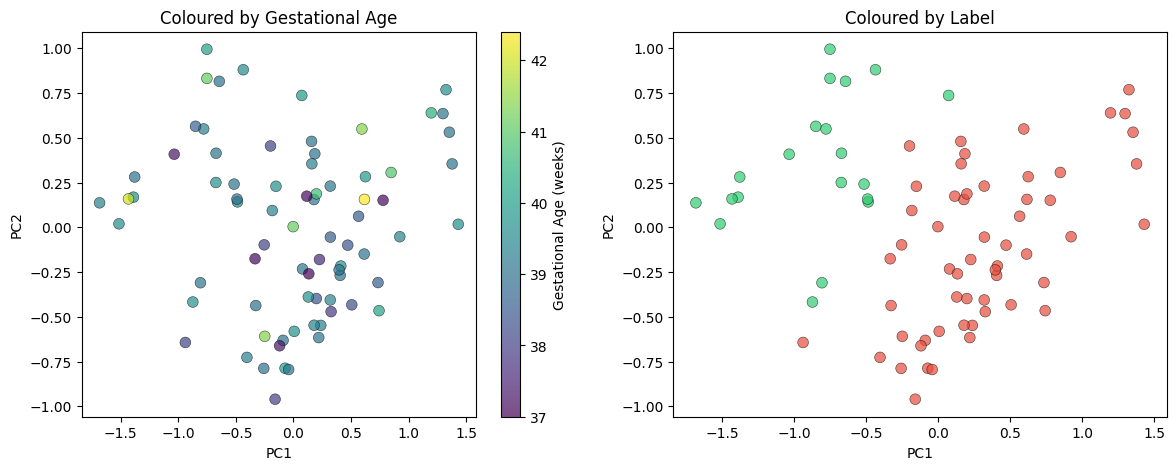

In [93]:
sex_col = meta_df.loc[X_train.index, 'sex'].map({
    'Sex: F': 'hotpink',
    'Sex: M': 'dodgerblue'
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [sex_col.values, None],
                           ['Coloured by Sex', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y_train.loc[X_train.index]]
    ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
plt.tight_layout()
plt.show()

#by gestational age
age_col = meta_df.loc[X_train.index, 'gestational_age'].map(
    lambda x: float(x.split(': ')[1].replace(' weeks', ''))
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [age_col.values, None],
                           ['Coloured by Gestational Age', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y_train.loc[X_train.index]]
    scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    if col is age_col.values:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Gestational Age (weeks)')
        

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)#, class_weight='balanced')

model.fit(X_train_kbest, y_train)

y_pred = model.predict(X_test_kbest)
y_train_pred = model.predict(X_train_kbest)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

   NonSmoker       1.00      0.50      0.67         4
      Smoker       0.89      1.00      0.94        16

    accuracy                           0.90        20
   macro avg       0.94      0.75      0.80        20
weighted avg       0.91      0.90      0.89        20


Confusion Matrix:
 [[ 2  2]
 [ 0 16]]


In [95]:
importances = model.feature_importances_

feature_names = X_train_filtered.columns[selector.get_support()]

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(10))

       feature  importance
34  cg27402634    0.147074
36  cg24714864    0.037713
83  cg26668911    0.032591
88  cg15605704    0.031303
64  cg07743644    0.030207
72  cg01485177    0.028908
43  cg11775807    0.021171
90  cg15412759    0.020230
33  cg08931687    0.019630
8   cg27119456    0.019194


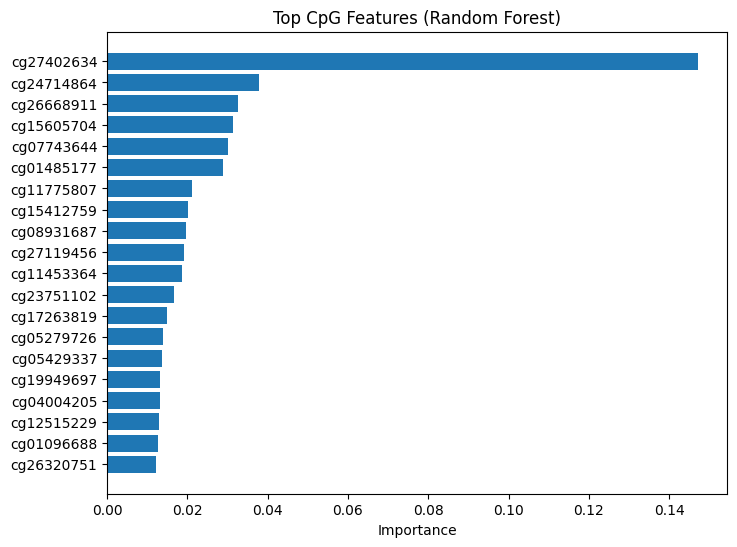

In [96]:
import matplotlib.pyplot as plt

top = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top CpG Features (Random Forest)")
plt.show()

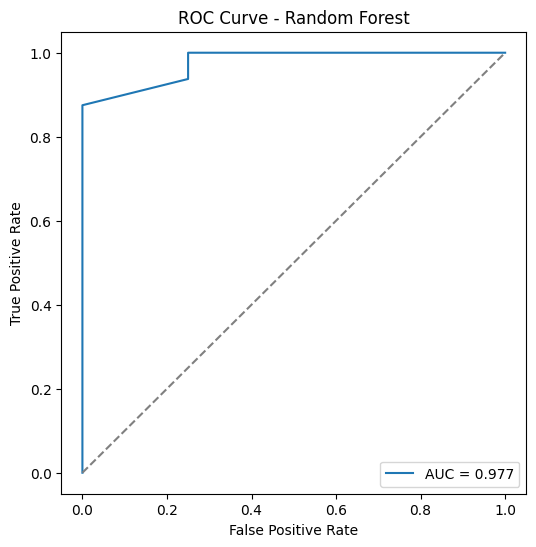

AUC: 0.9765625


In [97]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_prob =  model.predict_proba(X_test_kbest)

# If binary classification (Smoker vs NonSmoker)
# adjust class index if needed
positive_class_index = list(model.classes_).index("Smoker")

y_score = y_prob[:, positive_class_index]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label="Smoker")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC:", roc_auc)

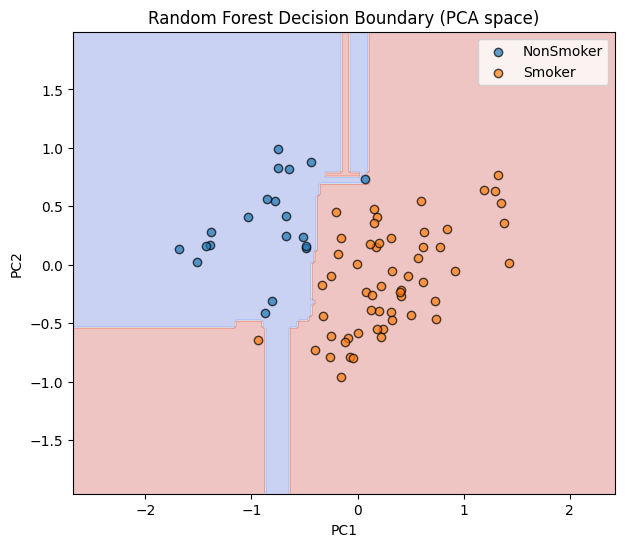

In [99]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_num = le.fit_transform(y_train)

pca_2d = PCA(n_components=2, random_state=42)

X_train_pca = pca_2d.fit_transform(X_train_kbest)
X_test_pca = pca_2d.transform(X_test_kbest)

rf_pca = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced',max_features='sqrt')

import numpy as np

x_min, x_max = X_train_pca[:,0].min() - 1, X_train_pca[:,0].max() + 1
y_min, y_max = X_train_pca[:,1].min() - 1, X_train_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

rf_pca.fit(X_train_pca, y_train_num)

Z = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

colors = {'Smoker': 'red', 'NonSmoker': 'green'}

for label in np.unique(y_train):
    idx = y_train == label
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        label=label,
        edgecolor='k',
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Random Forest Decision Boundary (PCA space)")
plt.legend()
plt.show()

In [102]:
!pip install shap


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


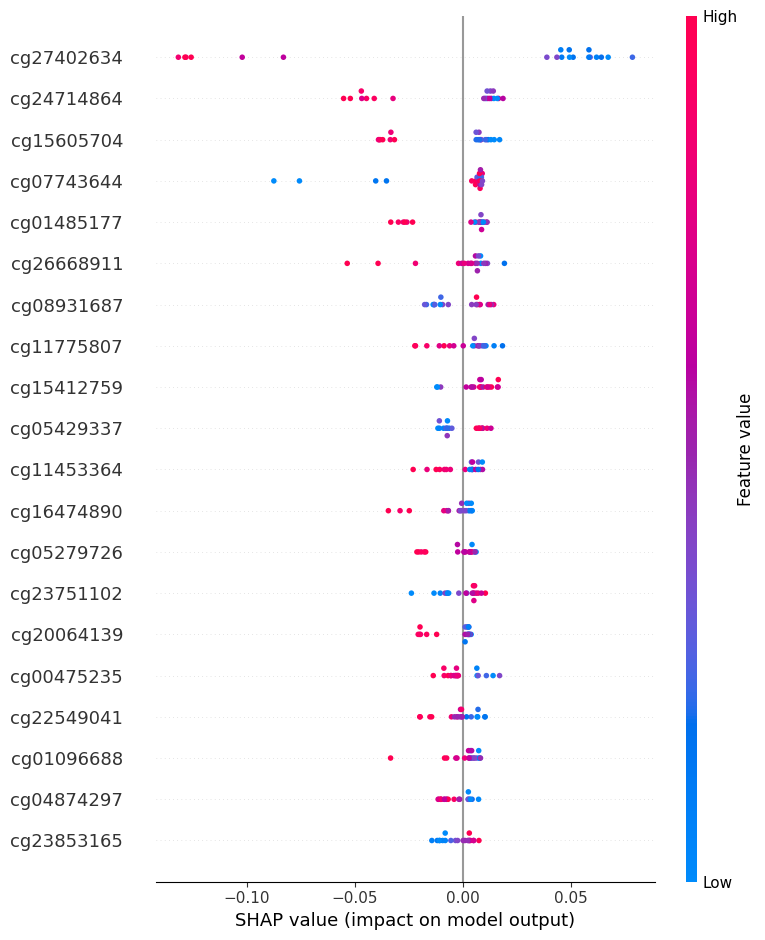

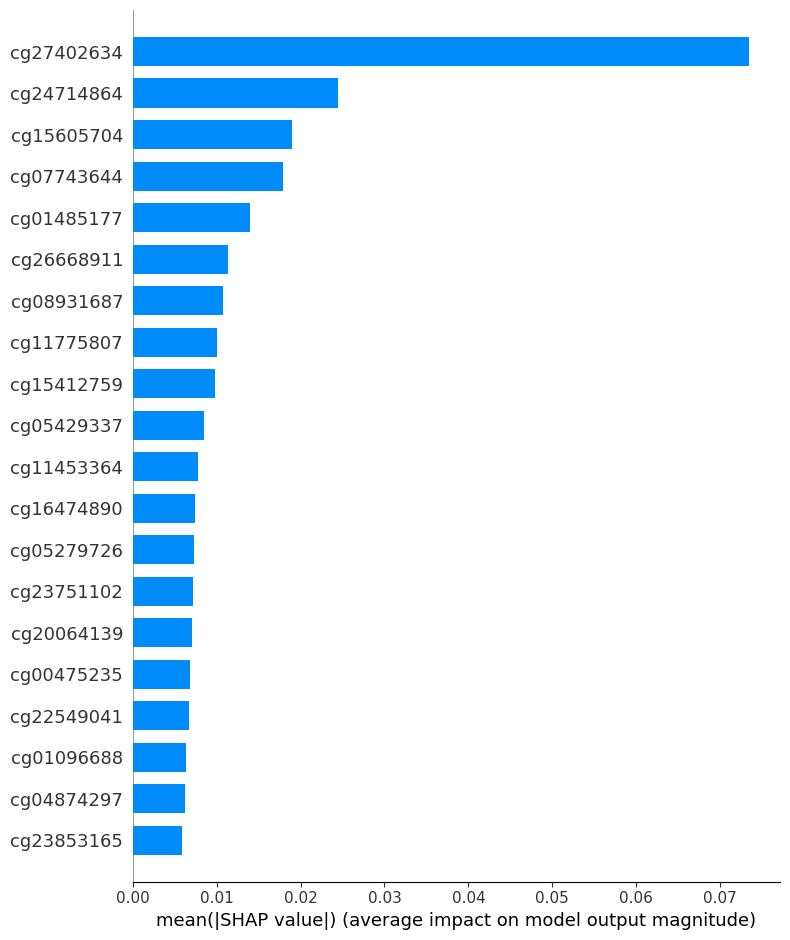

           CpG  mean_abs_SHAP
34  cg27402634       0.073461
36  cg24714864       0.024513
88  cg15605704       0.019011
64  cg07743644       0.017913
72  cg01485177       0.014026
83  cg26668911       0.011352
33  cg08931687       0.010760
43  cg11775807       0.010001
90  cg15412759       0.009749
91  cg05429337       0.008530
30  cg11453364       0.007820
26  cg16474890       0.007369
9   cg05279726       0.007291
13  cg23751102       0.007191
86  cg20064139       0.007069
50  cg00475235       0.006766
51  cg22549041       0.006704
21  cg01096688       0.006337
69  cg04874297       0.006275
6   cg23853165       0.005896


In [114]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_kbest)

selected_features = X_train_filtered.columns[selector.get_support()]

#print(type(shap_values))
#print(np.array(shap_values).shape)

shap_values_smoker = shap_values[:,:,1]

shap.summary_plot(
    shap_values_smoker,
    X_test_kbest,
    feature_names=selected_features
)

shap.summary_plot(
    shap_values_smoker,
    X_test_kbest,
    feature_names=selected_features,
    plot_type="bar"
)

#mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
mean_abs_shap = np.abs(shap_values_smoker).mean(axis=0)

shap_df = pd.DataFrame({
    "CpG": selected_features,
    "mean_abs_SHAP": mean_abs_shap
})

shap_df = shap_df.sort_values(
    "mean_abs_SHAP",
    ascending=False
)

print(shap_df.head(20))

In [125]:
"""!wget -O MethylationEPIC_v-1-0_B4.csv.gz \
"https://webdata.illumina.com/downloads/productfiles/methylationEPIC/infinium-methylationepic-v1-0-product-files.zip"

#unzip
zip_file = "MethylationEPIC_v-1-0_B4.csv.gz"
!gunzip $zip_file"""

!pip install methylprep

#manifest = pd.read_csv("MethylationEPIC_v-1-0_B4.csv", skiprows=7)

#manifest[manifest["IlmnID"] == "cg27402634"]


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [131]:
from methylprep.files import Manifest

manifest = Manifest(array_type='epic')

manifest.data_frame.head()


,AddressA_ID,AddressB_ID,Infinium_Design_Type,Color_Channel,CHR,MAPINFO,Strand,Genome_Build,OLD_CHR,OLD_MAPINFO,OLD_Strand,OLD_Genome_Build,probe_type
IlmnID,,,,,,,,,,,,,
cg07881041,85713262,<NA>,II,NaN,19,5236005.0,F,hg38,19,5236016.0,F,hg19,II
cg18478105,46761277,86644198,I,Grn,20,63216298.0,F,hg38,20,61847650.0,F,hg19,I
cg23229610,21717843,<NA>,II,NaN,1,6781065.0,F,hg38,1,6841125.0,F,hg19,II
cg03513874,29622133,<NA>,II,NaN,2,197438742.0,R,hg38,2,198303466.0,R,hg19,II
cg09835024,16745152,81631976,I,Red,X,24054523.0,F,hg38,X,24072640.0,F,hg19,I


In [132]:
manifest.data_frame.loc[
    manifest.data_frame.index == "cg27402634"
]

,AddressA_ID,AddressB_ID,Infinium_Design_Type,Color_Channel,CHR,MAPINFO,Strand,Genome_Build,OLD_CHR,OLD_MAPINFO,OLD_Strand,OLD_Genome_Build,probe_type
IlmnID,,,,,,,,,,,,,
cg27402634,79773354,<NA>,II,NaN,3,156819071.0,R,hg38,3,156536860.0,R,hg19,II
